# **Imports dan Global Config**

## *Import dan Filter Warning*

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.layers import Layer
from tensorflow.keras.callbacks import Callback

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

## *Heuristic Control dan Set GPU Memory Growth*

In [2]:
SEED = 42

def set_seed(SEED=42):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    print(f"Seed : {SEED}")

def set_gpu():
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
                gpu_details = tf.config.experimental.get_device_details(gpu)
                gpu_name = gpu_details.get('device_name', 'Unknown GPU')
                print(f"GPU  : {gpu_name}")
        except RuntimeError as e:
            print(e)
    else:
        print("Using CPU")

set_seed(SEED)
set_gpu()

Seed : 42
GPU  : Tesla T4


Untuk Heuristic control dan Reproducibility, saya set SEED = 42 sebagai konstanta global untuk konfigurasi randomness seed tensorflow dan numpy

# **Dataset Loading**

## *Load Dataset dari Google Drive*

In [3]:
csv_url = "https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr"
df_raw = pd.read_csv(csv_url)

print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (53150, 7)


,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


## *Simple EDA yaitu info, statistik dan analisis null value*

In [4]:
print("-" * 75)
print("DATASET INFO")
print("-" * 75)
print(df_raw.info())
print()

print("-" * 75)
print("DATASET STATISTIC")
print("-" * 75)
print(df_raw.describe().round(2))
print()

print("-" * 75)
print("DATASET NULL VALUE")
print("-" * 75)
print(df_raw.isnull().sum())
print()

---------------------------------------------------------------------------
DATASET INFO
---------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB
None

---------------------------------------------------------------------------
DATASET STATISTIC
---------------------------------------------------------------------------
          Close   Volume USDT       RSI  MACD_Hist       ATR     KAMAO
count  53150.00  5.315000e+04  53150.00   53150.00

# **Feature Engineering**

In [5]:
df = df_raw.copy()

df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df.set_index("Date", inplace=True)
df = df.sort_index()

df["Rolling_Mean_24"]  = df["Close"].rolling(window=24).mean()
df["Rolling_Std_24"]   = df["Close"].rolling(window=24).std()
df["Rolling_Mean_7d"]  = df["Close"].rolling(window=168).mean()
df["Rolling_Max_24"]   = df["Close"].rolling(window=24).max()
df["Rolling_Min_24"]   = df["Close"].rolling(window=24).min()
df["Rolling_Range_24"] = df["Rolling_Max_24"] - df["Rolling_Min_24"]

def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window=window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window=window).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

df["RSI"] = compute_rsi(df["Close"], window=14)

ema_12              = df["Close"].ewm(span=12, adjust=False).mean()
ema_26              = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]          = ema_12 - ema_26
df["MACD_Signal"]   = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Hist"]     = df["MACD"] - df["MACD_Signal"]

df["ATR"]           = df["Rolling_Std_24"] * 1.5

df["Log_Return"]    = np.log(df["Close"] / df["Close"].shift(1))
df["Momentum_12h"]  = df["Close"] - df["Close"].shift(12)
df["Momentum_24h"]  = df["Close"] - df["Close"].shift(24)

df["Volume_Rolling_Mean"] = df["Volume USDT"].rolling(window=24).mean()
df["Volume_Ratio"]        = df["Volume USDT"] / (df["Volume_Rolling_Mean"] + 1e-10)

df.dropna(inplace=True)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (52983, 19)


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_7d,Rolling_Max_24,Rolling_Min_24,Rolling_Range_24,MACD,MACD_Signal,Log_Return,Momentum_12h,Momentum_24h,Volume_Rolling_Mean,Volume_Ratio
Date,,,,,,,,,,,,,,,,,,,
2017-09-28 08:00:00,4267.89,114734.576233,69.662842,0.583931,111.762616,6.906941,4155.957083,74.508411,3817.396369,4267.89,3970.0,297.89,63.493458,62.909527,0.005142,72.89,330.38,135557.457743,0.846391
2017-09-28 09:00:00,4256.56,111030.999092,62.747051,-0.274842,98.810074,6.732094,4167.897083,65.873383,3819.756845,4267.89,4055.0,212.89,62.565974,62.840816,-0.002658,49.02,286.56,138520.678220,0.801548
2017-09-28 10:00:00,4148.00,204461.536029,43.555287,-8.299650,94.574121,5.215396,4170.920833,63.049414,3821.402798,4267.89,4055.0,212.89,52.466253,60.765904,-0.025835,-59.95,72.57,136604.993936,1.496735
2017-09-28 11:00:00,4180.00,189114.033313,46.414996,-11.406189,89.261731,5.627300,4175.379167,59.507821,3823.278095,4267.89,4055.0,212.89,46.508167,57.914356,0.007685,-13.00,107.00,131709.842395,1.435838
2017-09-28 12:00:00,4189.02,241152.047033,47.589825,-12.707735,85.699501,5.725403,4179.228750,57.133001,3825.247976,4267.89,4055.0,212.89,42.029688,54.737423,0.002156,37.00,92.39,136988.403043,1.760383


Berikut penjelasan dari Feature Engineering
*   `Rolling Mean 24 dan 7 hari`: saya menambahkan fitur tersebut untuk melihat rata rata dari 24 periode dan 7 hari untuk membantu melihat harga tren secara umum, apakah sedang naik atau turun
*   `Rolling Std 24`: Fitur tersebut ditambahkan untuk melihat volatilitas pasar dalam 24 periode
* `Rolling Max, Min, range 24`: Fitur tersebut ditambahkan untuk melihat harga tertinggi, terendah dan selisih dalam 24 periode agar model mendapat gambaran batas pergerakan harga
* `RSI`: meskipun sudah ada dalam dataset, saya menghitung hulang untuk memastikan konsistensi sekaligus melihat apakah aset sudah terlalu mahal (overbought) atau terlalu murah (oversold)
* `MACD`: fitur tersebut ditambahkan guna melihat momentum perubahan harga
*`ATR`: Fitur tersebut didapad dari STD x 1.5 untuk mengukur volatilitas harian
* `Log return`: Saya menambah fungsi logaritmik dari perubahan harga untuk melihat persentase return secara lebih stabil
* `momentum 12h dan 24h`: Saya hitung selisih harga dengan 12 dan 24 periode lalu. Ini memberi tahu saya seberapa kuat pergerakan harga dalam 12-24 jam terakhir
* `Volume Rolling Mean 24`: Rata-rata volume 24 periode terakhir.
* `Volume Ratio`: Perbandingan volume saat ini dengan rata-ratanya. Rasio >1 berarti volume di atas normal, menandakan minat tinggi.


# **Feature Selection**

In [6]:
SELECTED_FEATURES = [
    "Close",
    "Volume USDT",
    "RSI",
    "MACD_Hist",
    "ATR",
    "Rolling_Mean_24",
    "Rolling_Std_24",
    "Rolling_Range_24",
    "Log_Return",
    "Volume_Ratio",
]

SELECTED_FEATURES = [feature for feature in SELECTED_FEATURES if feature in df.columns]
TARGET_COL        = "Close"

TARGET_IDX  = SELECTED_FEATURES.index(TARGET_COL)
df_selected = df[SELECTED_FEATURES].copy()

print(f"Fitur  : {SELECTED_FEATURES[1:]}")
print(f"Target : {TARGET_COL}")

df_selected.head()

Fitur  : ['Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'Rolling_Mean_24', 'Rolling_Std_24', 'Rolling_Range_24', 'Log_Return', 'Volume_Ratio']
Target : Close


,Close,Volume USDT,RSI,MACD_Hist,ATR,Rolling_Mean_24,Rolling_Std_24,Rolling_Range_24,Log_Return,Volume_Ratio
Date,,,,,,,,,,
2017-09-28 08:00:00,4267.89,114734.576233,69.662842,0.583931,111.762616,4155.957083,74.508411,297.89,0.005142,0.846391
2017-09-28 09:00:00,4256.56,111030.999092,62.747051,-0.274842,98.810074,4167.897083,65.873383,212.89,-0.002658,0.801548
2017-09-28 10:00:00,4148.00,204461.536029,43.555287,-8.299650,94.574121,4170.920833,63.049414,212.89,-0.025835,1.496735
2017-09-28 11:00:00,4180.00,189114.033313,46.414996,-11.406189,89.261731,4175.379167,59.507821,212.89,0.007685,1.435838
2017-09-28 12:00:00,4189.02,241152.047033,47.589825,-12.707735,85.699501,4179.228750,57.133001,212.89,0.002156,1.760383


* `Close`: Target prediksi (harga penutupan)
* `Volume USDT`: Aktivitas pasar, tinggi = minat besar
* `RSI`: Indikator jenuh beli (70+) / jual (30-)
* `MACD_Hist`: Momentum harga, positif = naik, negatif = turun
* `ATR`: Volatilitas, besar = gerak liar, kecil = tenang
* `Rolling_Mean_24`: Tren jangka pendek (rata-rata 24 periode)
* `Rolling_Std_24`: Stabilitas harga (penyimpangan dari rata-rata)
* `Rolling_Range_24`: Lebar pergerakan harga (max - min)
* `Log_Return`: Persentase perubahan harga bentuk logaritma
* `Volume_Ratio`: Volume normal (>1) atau sepi (<1)

# **EDA Correlation, Price x Close, dan Time Series Decomposition**

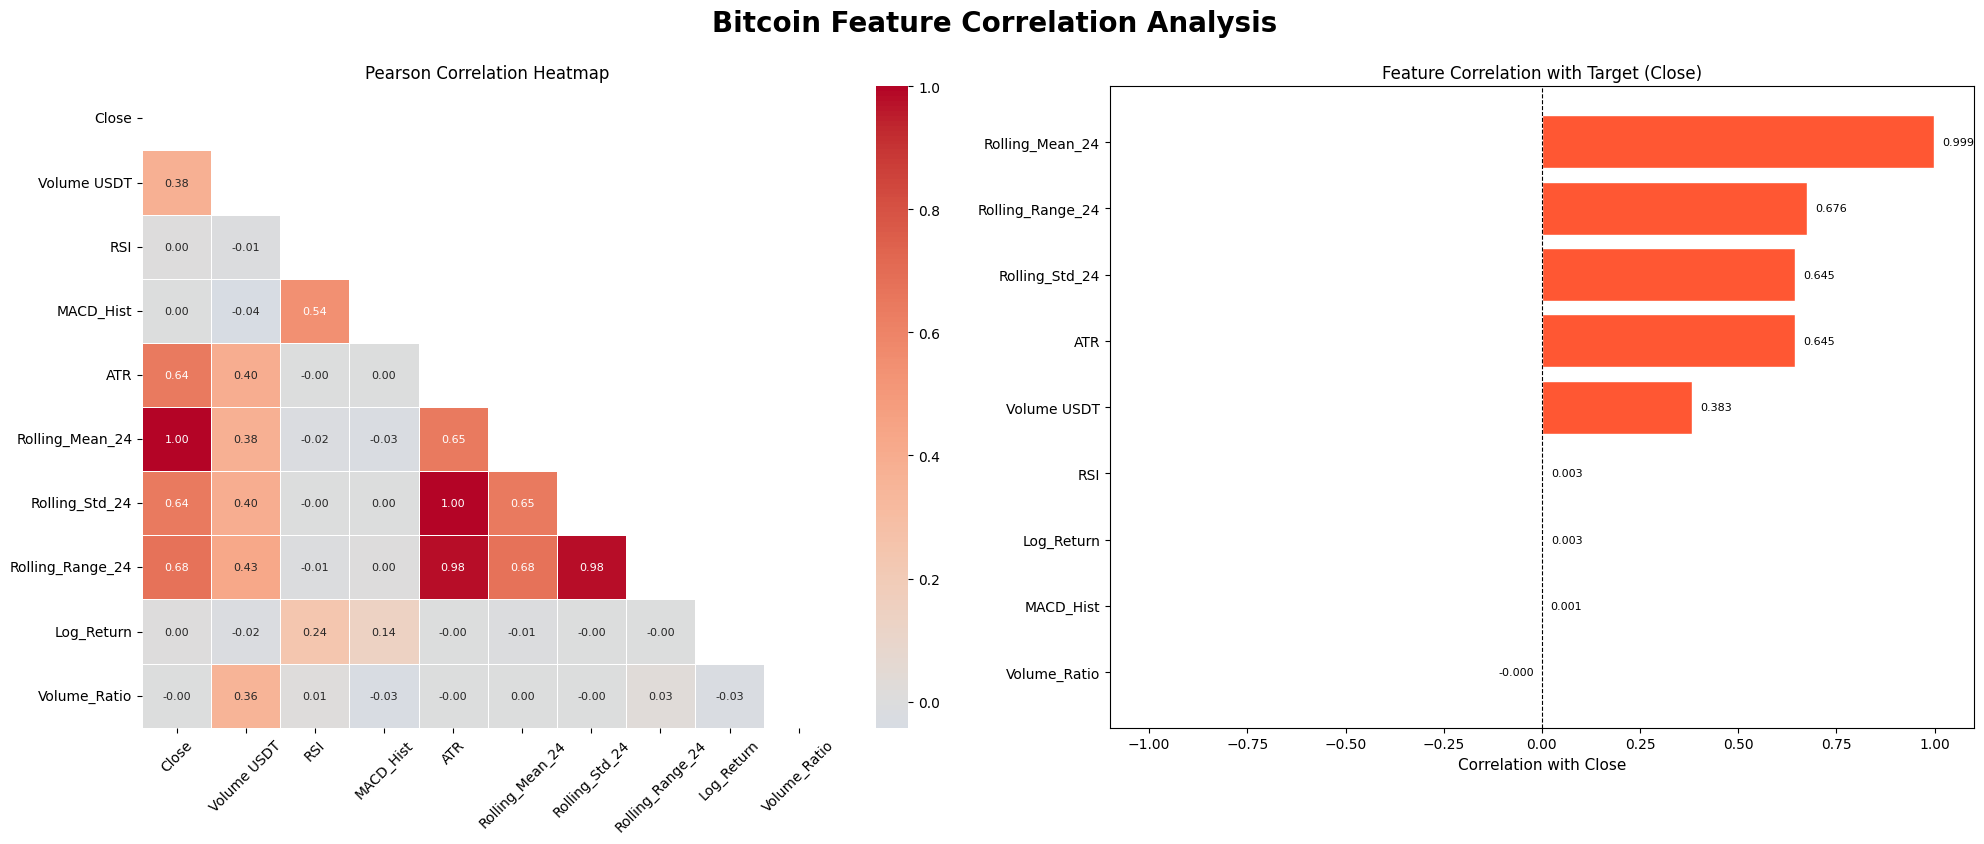

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

corr_matrix = df_selected.corr(method="pearson", numeric_only=True)
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=axes[0],
    mask=mask,
    annot_kws={"size": 8},
)

axes[0].set_title("Pearson Correlation Heatmap")
axes[0].tick_params(axis="x", rotation=45)

corr_with_target = (
    df_selected.corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(ascending=True)
)

axes[1].barh(
    corr_with_target.index,
    corr_with_target.values,
    color='#FF5733',
    edgecolor="white",
)

axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Correlation with Close", fontsize=11)
axes[1].set_title(f"Feature Correlation with Target ({TARGET_COL})")
axes[1].set_xlim(-1.1, 1.1)

for i, (val, name) in enumerate(zip(corr_with_target.values, corr_with_target.index)):
    axes[1].text(
        val + 0.02 if val >= 0 else val - 0.02,
        i,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=8,
    )

plt.tight_layout()
plt.suptitle("Bitcoin Feature Correlation Analysis", fontsize=20, fontweight="bold", y=1.05)
plt.show()

Dari 9 fitur yang dianalisis, saya menemukan dua kelompok utama dengan karakteristik sangat berbeda:

**Kelompok Relevan Tinggi (korelasi > 0.6):**
`Rolling_Mean_24`, `Rolling_Range_24`, `Rolling_Std_24`, dan `ATR` memiliki hubungan kuat dengan harga `Close`. Ini masuk akal karena fitur-fitur ini pada dasarnya adalah turunan langsung dari harga atau volatilitas. Namun `Rolling_Mean_24` (r=0.999) perlu diwaspadai karena berisiko data leakage.

**Kelompok Relevan Rendah (korelasi mendekati nol):**
`RSI`, `Log_Return`, `MACD_Hist`, dan `Volume_Ratio` hampir tidak berkorelasi linear dengan `Close`. Ini bukan kelemahan, justru menurut saya sesuai desainnya sebagai osilator dan fitur perubahan relatif yang bersifat stationary.

**Masalah Redundansi:**
Saya perlu mengatasi multikolinearitas tinggi antara `Rolling_Std_24` dan `Rolling_Range_24` (r=0.98) karena keduanya mengukur hal yang hampir sama.

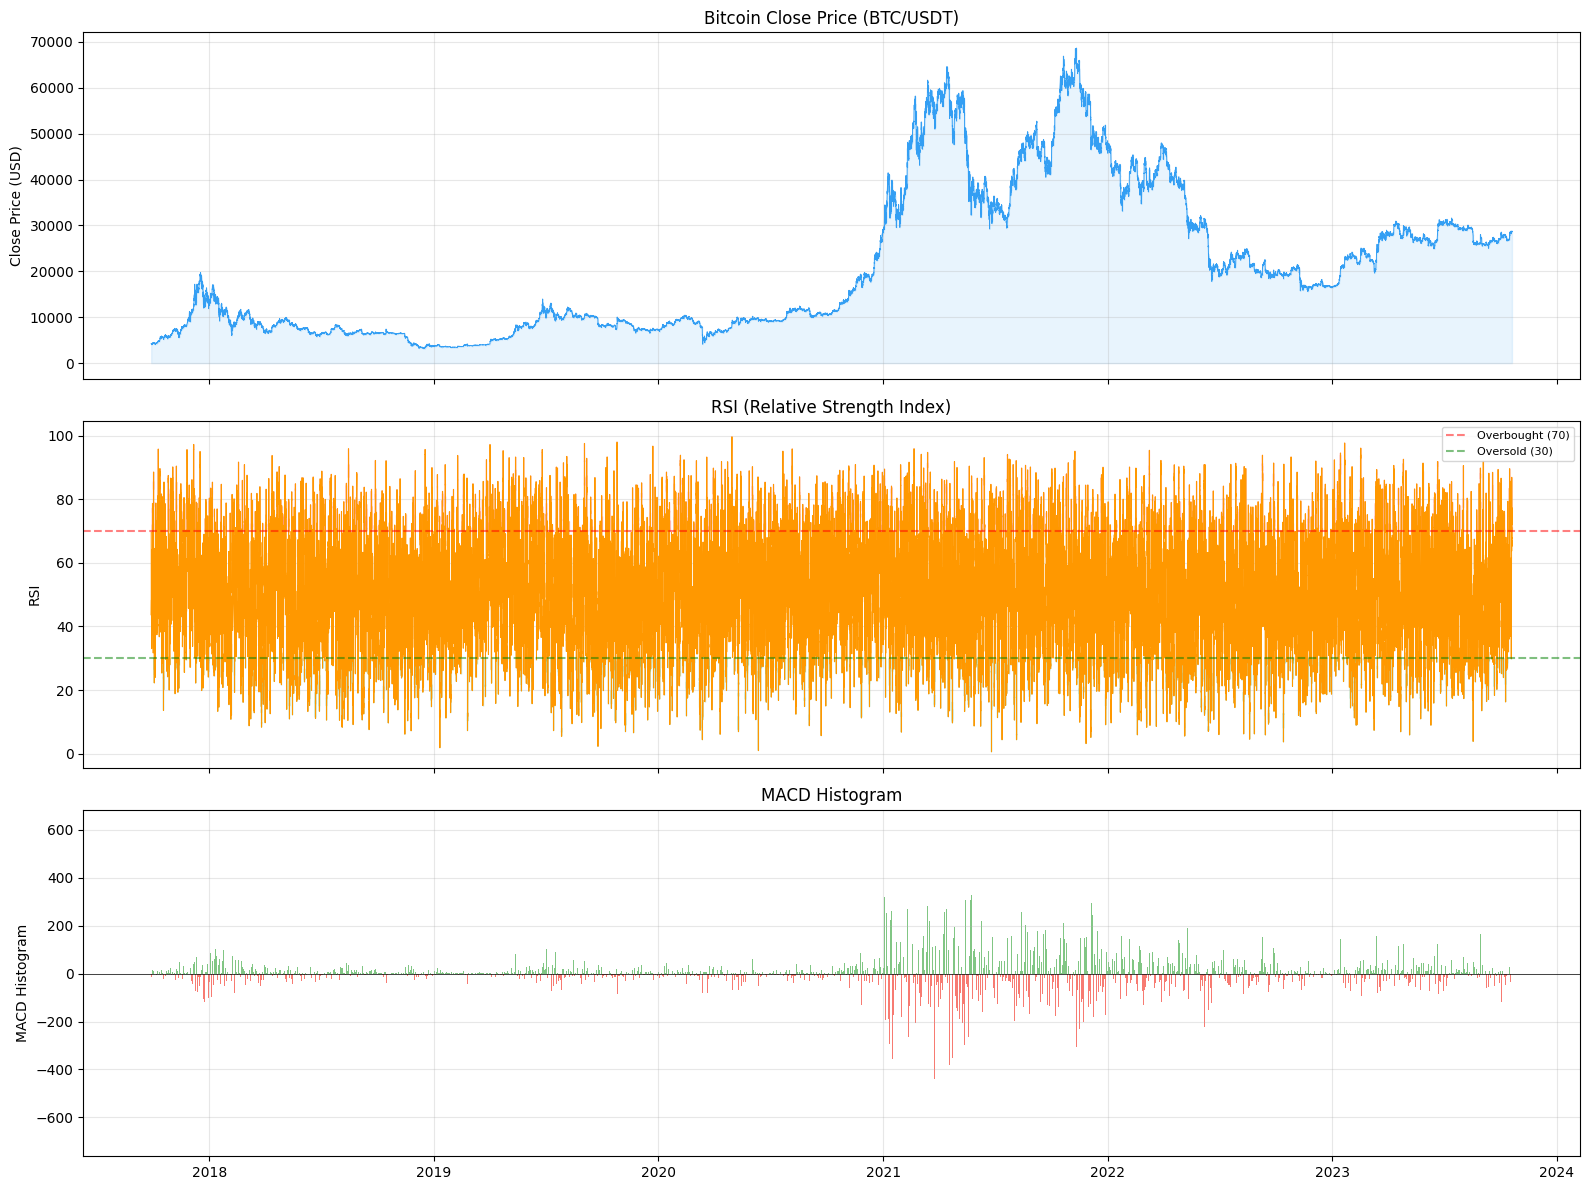

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(
    df_selected.index,
    df_selected["Close"],
    color="#2196F3",
    linewidth=0.7,
    alpha=0.9,
)

axes[0].fill_between(df_selected.index, df_selected["Close"], alpha=0.1, color="#2196F3")
axes[0].set_ylabel("Close Price (USD)", fontsize=10)
axes[0].set_title("Bitcoin Close Price (BTC/USDT)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    df_selected.index,
    df_selected["RSI"],
    color="#FF9800",
    linewidth=0.7,
)

axes[1].axhline(70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")

axes[1].fill_between(
    df_selected.index,
    70,
    df_selected["RSI"],
    where=df_selected["RSI"] > 70,
    alpha=0.2,
    color="red",
)

axes[1].fill_between(
    df_selected.index,
    30,
    df_selected["RSI"],
    where=df_selected["RSI"] < 30,
    alpha=0.2,
    color="green",
)

axes[1].set_ylabel("RSI", fontsize=10)
axes[1].set_title("RSI (Relative Strength Index)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.3)

pos_mask = df_selected["MACD_Hist"] >= 0

axes[2].bar(
    df_selected.index[pos_mask],
    df_selected["MACD_Hist"][pos_mask],
    color="#4CAF50",
    alpha=0.7,
    width=0.04,
)

axes[2].bar(
    df_selected.index[~pos_mask],
    df_selected["MACD_Hist"][~pos_mask],
    color="#F44336",
    alpha=0.7,
    width=0.04,
)

axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_ylabel("MACD Histogram", fontsize=10)
axes[2].set_title("MACD Histogram")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Berdasarkan grafik harga Bitcoin selama 7 tahun, saya melihat tiga siklus pasar yang jelas. Siklus pertama (2017-2018) menunjukkan rally ke 20.000 dolar kemudian koreksi tajam ke 3.000-4.000 dolar. Siklus kedua (2019-2020) adalah fase akumulasi dengan harga bergerak sideways. Siklus ketiga (2020-2022) merupakan yang terbesar, dengan harga melonjak ke 67.000 dolar lalu jatuh ke 15.000-16.000 dolar. Fase pemulihan 2023 menunjukkan kenaikan bertahap ke kisaran 25.000-30.000 dolar.

Untuk RSI pada data per jam, saya mengamati volatilitas ekstrem dengan osilasi yang konsisten ke seluruh rentang 0-100. RSI secara reguler menembus level overbought 70 dan oversold 30 sepanjang periode, tanpa pernah terjebak di satu sisi. Ini mengkonfirmasi bahwa RSI tidak berkorelasi linear dengan level harga absolut, meskipun mengandung informasi momentum non-linear yang berguna untuk LSTM.

Untuk MACD Histogram, saya melihat perubahan rezim yang sangat jelas. Pada fase 2017-2020, histogram bergerak rapat di sekitar nol dengan amplitudo kecil. Pada fase 2021-2022, amplitudo meledak jauh lebih besar dengan bar hijau panjang di fase bull dan bar merah panjang di fase bear. Ini adalah bukti visual non-stationarity yang kuat. Pada fase 2023, amplitudo kembali mereda namun masih lebih besar dibanding era pra-2020, konsisten dengan level harga yang lebih tinggi secara absolut.

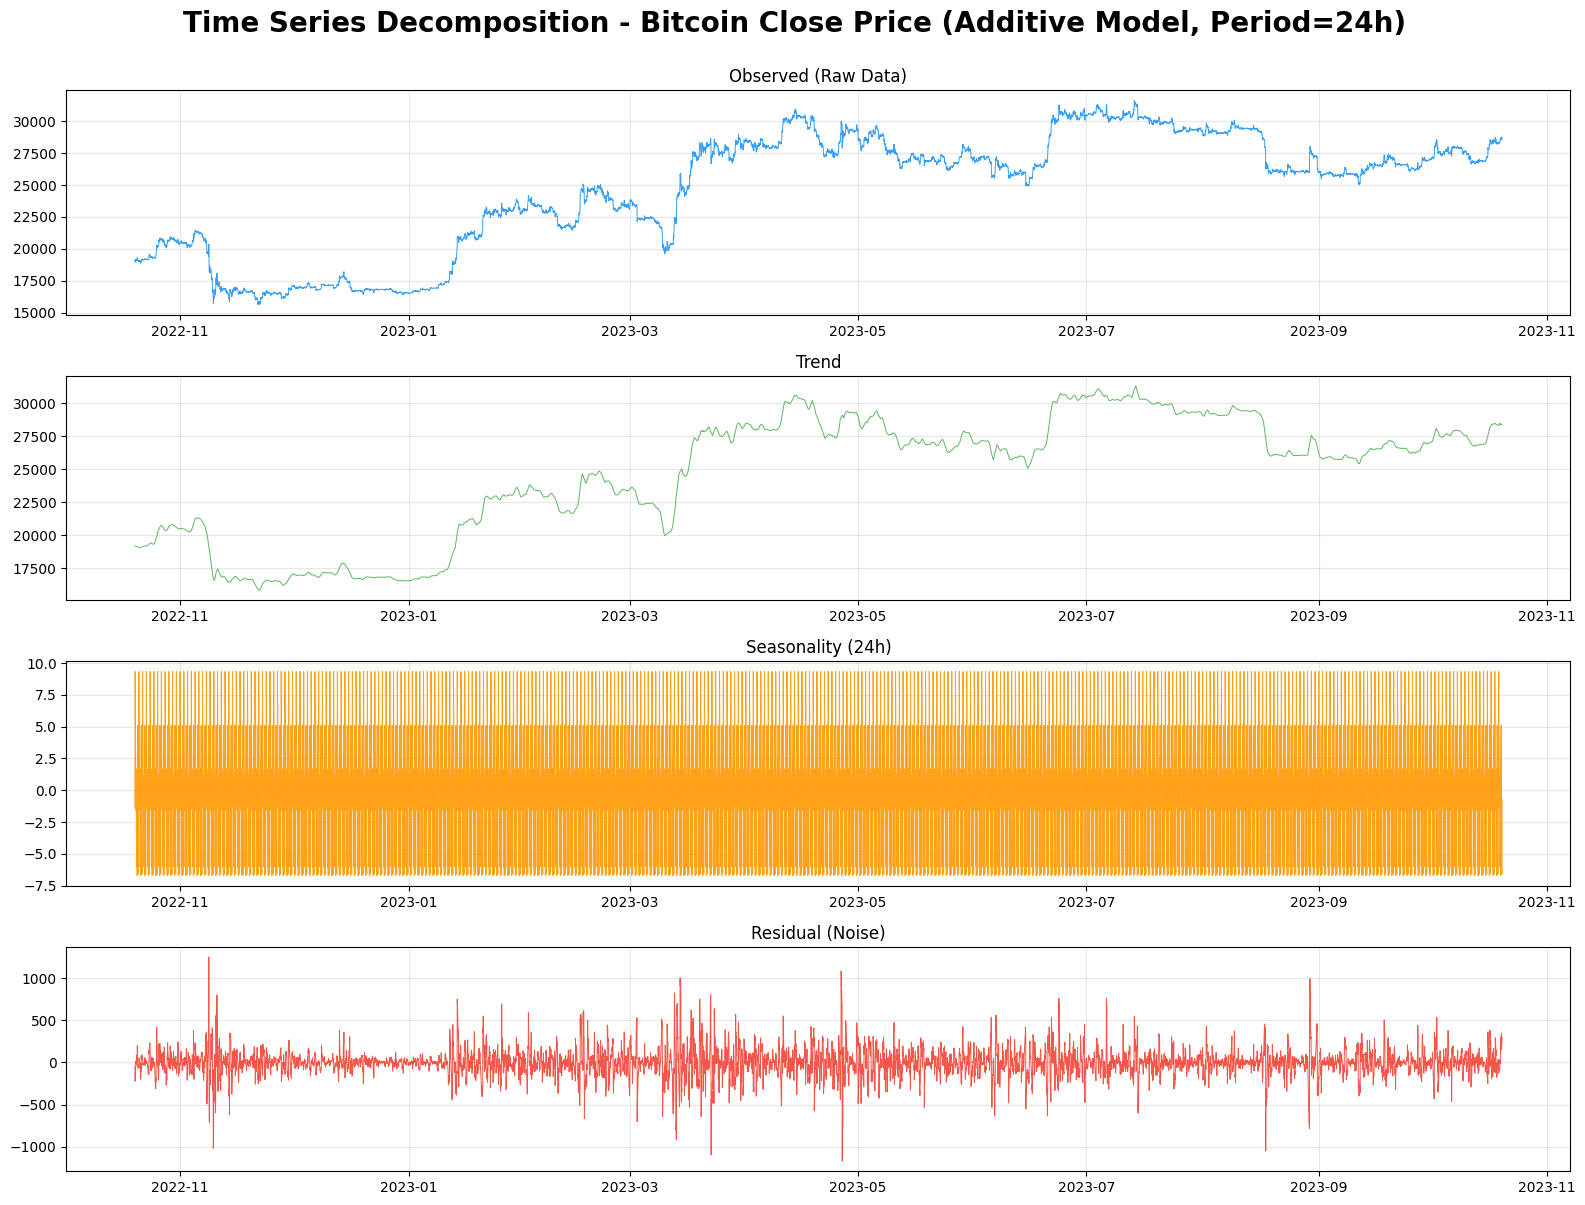

In [9]:
close_sample = df_selected["Close"].iloc[-8760:]

decomposition = seasonal_decompose(
    close_sample,
    model="additive",
    period=24,
    extrapolate_trend="freq",
)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle("")

components = [
    (decomposition.observed, "Observed (Raw Data)", "#2196F3"),
    (decomposition.trend, "Trend", "#4CAF50"),
    (decomposition.seasonal, "Seasonality (24h)", "#FF9800"),
    (decomposition.resid, "Residual (Noise)", "#F44336"),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=0.7, alpha=0.9)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("Time Series Decomposition - Bitcoin Close Price (Additive Model, Period=24h)", fontsize=20, fontweight="bold", y=1.)
plt.tight_layout()
plt.show()

**Kesimpulan Analisis Dekomposisi Time Series**

Berdasarkan dekomposisi data 1 tahun terakhir (Oktober 2022 hingga Oktober 2023), saya melihat fase yang sangat strategis dalam siklus Bitcoin. Periode ini mencakup bottom bear market di 15.000-17.000 dolar, fase recovery awal, mini bull run hingga 30.000 dolar, dan konsolidasi panjang di kisaran 25.000-31.000 dolar.

Untuk komponen tren, saya mengamati beberapa fase berurutan. Pertama adalah downtrend residual pada Oktober hingga November 2022 sebagai ekor dari crash akibat kolaps FTX. Kemudian terjadi inflection point dan recovery dari Desember 2022 hingga Maret 2023 dengan kenaikan smooth dari 17.000 ke 25.000 dolar. Selanjutnya terjadi breakout tajam pada Februari hingga April 2023 dengan harga menembus 30.000 dolar. Terakhir adalah fase distribusi dan konsolidasi dari Mei hingga Oktober 2023 dengan pergerakan sideways tanpa arah yang jelas.

Untuk komponen seasonality 24 jam, saya menemukan amplitudo sangat kecil sekitar 7.5 dolar, hanya 0.03-0.05 persen dari level harga Bitcoin. Polanya sangat reguler dan stabil sepanjang periode tanpa perubahan amplitudo maupun fase. Ini mencerminkan pola aktivitas trading harian global, namun karena amplitudo kecil, seasonality memiliki rasio signal-to-noise rendah dan tidak material untuk prediksi harga.

Untuk komponen residual, saya mengidentifikasi karakteristik heteroskedastisitas dimana amplitudo bervariasi sepanjang waktu. Beberapa periode memiliki spike besar hingga 1000 dolar seperti saat FTX collapse November 2022 dan krisis Silicon Valley Bank Maret 2023, sementara periode lain lebih tenang di kisaran 100-200 dolar. Saya juga melihat volatility clustering dimana spike besar cenderung muncul berdekatan.

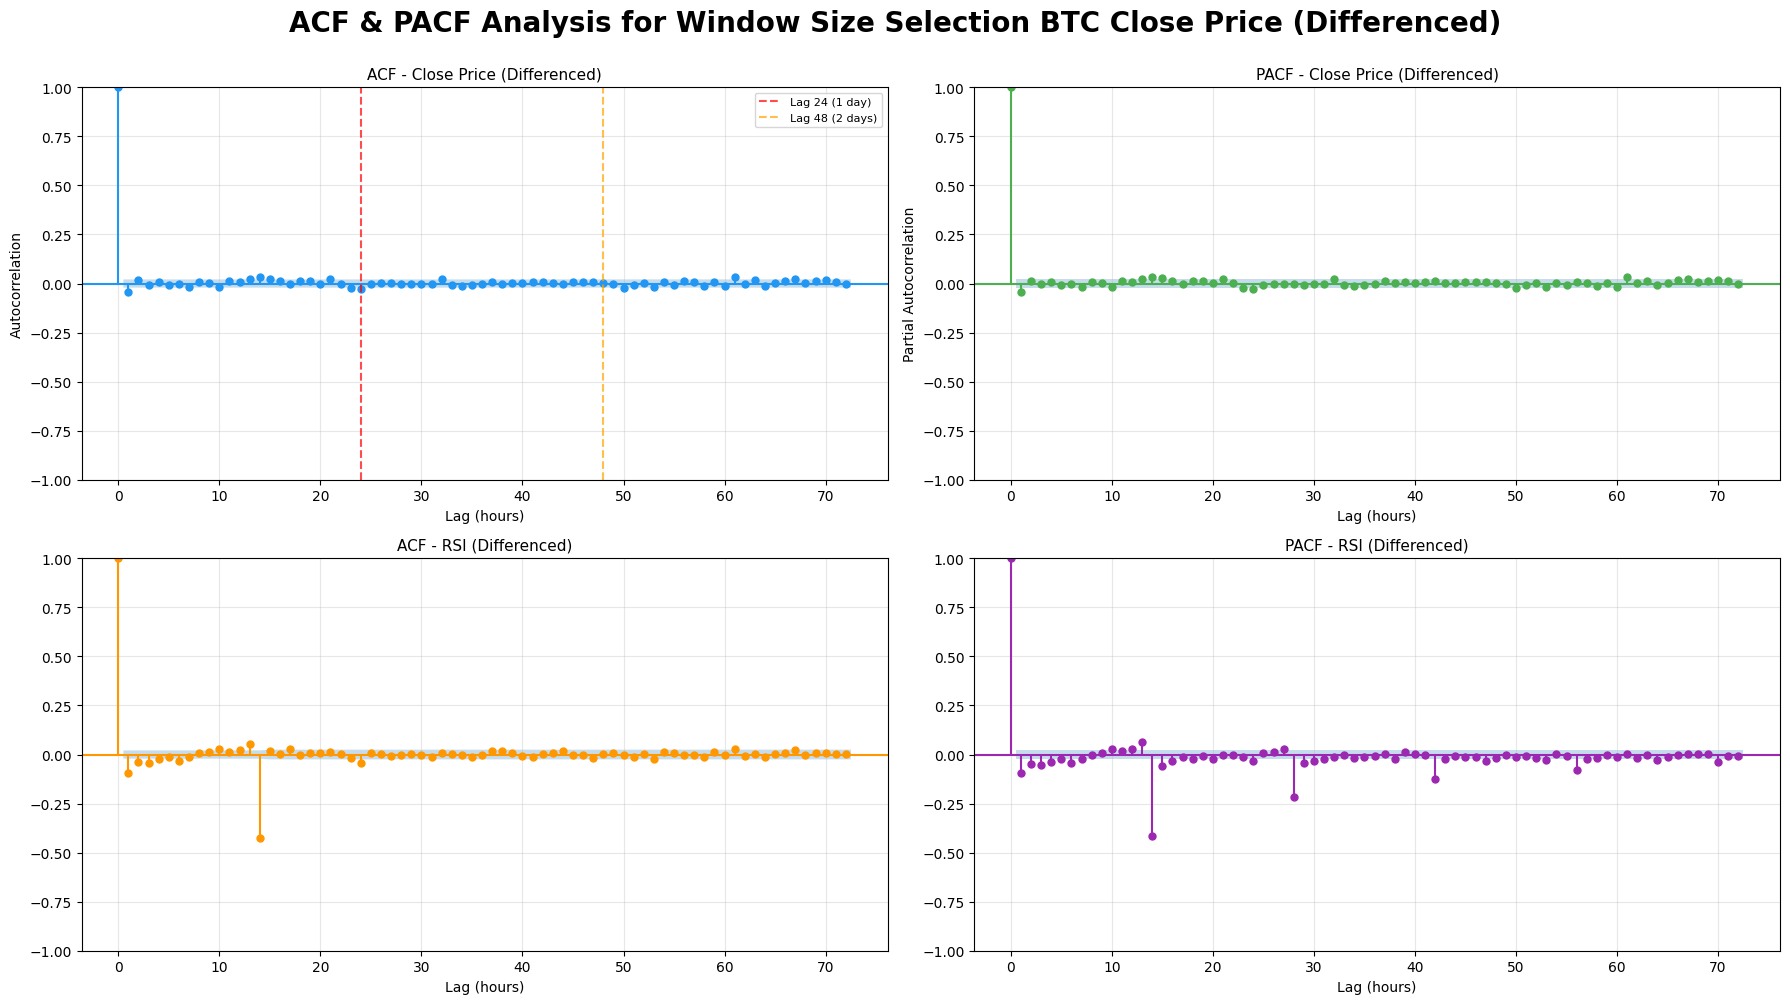

In [10]:
close_diff = close_sample.diff().dropna()
n_lags     = 72

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

plot_acf(
    close_diff,
    lags=n_lags,
    ax=axes[0, 0],
    alpha=0.05,
    color="#2196F3",
    vlines_kwargs={"colors": "#2196F3"},
)

axes[0, 0].set_title("ACF - Close Price (Differenced)", fontsize=11)
axes[0, 0].set_xlabel("Lag (hours)")
axes[0, 0].set_ylabel("Autocorrelation")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(24, color="red", linestyle="--", alpha=0.7, label="Lag 24 (1 day)")
axes[0, 0].axvline(48, color="orange", linestyle="--", alpha=0.7, label="Lag 48 (2 days)")
axes[0, 0].legend(fontsize=8)

plot_pacf(
    close_diff,
    lags=n_lags,
    ax=axes[0, 1],
    alpha=0.05,
    method="ywm",
    color="#4CAF50",
    vlines_kwargs={"colors": "#4CAF50"},
)

axes[0, 1].set_title("PACF - Close Price (Differenced)", fontsize=11)
axes[0, 1].set_xlabel("Lag (hours)")
axes[0, 1].set_ylabel("Partial Autocorrelation")
axes[0, 1].grid(True, alpha=0.3)

rsi_series = df_selected["RSI"].iloc[-8760:].diff().dropna()

plot_acf(
    rsi_series,
    lags=n_lags,
    ax=axes[1, 0],
    alpha=0.05,
    color="#FF9800",
    vlines_kwargs={"colors": "#FF9800"},
)

axes[1, 0].set_title("ACF - RSI (Differenced)", fontsize=11)
axes[1, 0].set_xlabel("Lag (hours)")
axes[1, 0].grid(True, alpha=0.3)

plot_pacf(
    rsi_series,
    lags=n_lags,
    ax=axes[1, 1],
    alpha=0.05,
    method="ywm",
    color="#9C27B0",
    vlines_kwargs={"colors": "#9C27B0"},
)

axes[1, 1].set_title("PACF - RSI (Differenced)", fontsize=11)
axes[1, 1].set_xlabel("Lag (hours)")
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("ACF & PACF Analysis for Window Size Selection BTC Close Price (Differenced)", fontsize=20, fontweight="bold", y=1.)
plt.tight_layout()
plt.show()

Dari analisis autokorelasi ini, saya mendapatkan tiga temuan utama untuk menentukan window size LSTM.

**Untuk Harga Close yang sudah di-differencing**, saya melihat ACF turun mendekati nol hampir seketika setelah lag 1. Tidak ada spike signifikan di lag 24 maupun 48. Ini berarti perubahan harga Bitcoin per jam hampir tidak memiliki hubungan linear dengan perubahan jam-jam sebelumnya. Data ini mendekati white noise atau random walk.

**Untuk RSI yang sudah di-differencing**, saya menemukan spike negatif besar di lag 14 dan 28. Namun ini bukan sinyal pasar yang sebenarnya, melainkan artefak matematis dari konstruksi RSI dengan periode 14. Pola ini muncul karena RSI dihitung berdasarkan 14 periode sebelumnya, sehingga selisih RSI otomatis berkorelasi negatif dengan versi 14 jam sebelumnya.

**Implikasi untuk window size**, ACF dan PACF yang drop ke nol secara linear menunjukkan tidak ada justifikasi statistik untuk menggunakan window panjang berdasarkan korelasi linear. Namun LSTM mampu menangkap pola non-linear yang tidak terdeteksi oleh ACF. Oleh karena itu, window 24 hingga 72 jam tetap relevan untuk memberikan konteks tren meskipun hubungan linear antar jam sangat lemah.

# **Model Training**

## *Konfigurasi Hyperparameter*

In [11]:
WINDOW_SIZE   = 48
HORIZON       = 24
N_FEATURES    = len(SELECTED_FEATURES)
BATCH_SIZE    = 64
EPOCHS        = 30
LEARNING_RATE = 1e-3

**WINDOW_SIZE = 48 (2 hari)**
Saya memilih 48 jam berdasarkan hasil ACF yang menunjukkan hubungan linear antar jam sangat lemah. Namun model tetap butuh konteks tren yang cukup. Window 48 jam mencakup 2 siklus harian penuh, sehingga model bisa membandingkan kondisi kemarin dengan hari ini. Ini adalah titik ideal antara informasi yang cukup dan efisiensi komputasi.

**HORIZON = 24 (1 hari ke depan)**
Saya memilih prediksi 24 jam karena ini adalah siklus alami pasar kripto. Perbandingan horizon terhadap window adalah 0.5, proporsi yang sehat. Jika prediksi terlalu jauh relatif terhadap jendela pengamatan, akurasi akan turun drastis karena sifat harga Bitcoin yang mendekati random walk.

**N_FEATURES = jumlah fitur terpilih**
Saya membuat parameter ini dinamis mengikuti fitur yang digunakan. Praktik ini benar karena input shape model selalu konsisten dengan data tanpa perlu mengubah kode keras saat fitur berubah.

**BATCH_SIZE = 64**
Saya memilih 64 karena menyeimbangkan dua hal. Jika batch terlalu kecil (8-16), gradien menjadi berisik dan training lambat. Jika terlalu besar (256+), kemampuan generalisasi menurun karena gradien terlalu mulus. Dengan data jam-jaman yang besar, 64 memberikan gradien stabil dengan variasi cukup untuk regularisasi alami.

**EPOCHS = 30**
Saya memilih 30 epoch karena cukup untuk konvergensi awal tanpa overfitting berlebihan, asalkan dipasangkan dengan EarlyStopping. Untuk model LSTM dengan attention, 30 epoch adalah titik awal yang aman. Model tetap bisa dilanjutkan jika kurva loss belum landai.

**LEARNING_RATE = 1e-3**
Ini adalah nilai default Adam yang terbukti sebagai awal terbaik untuk sebagian besar model deep learning. Nilai 1e-3 memberikan langkah update cukup besar untuk konvergensi cepat di awal. Nanti bisa saya turunkan menggunakan ReduceLROnPlateau saat mendekati titik optimal.

## *Split Train/Val/Test dan Scaling*

In [12]:
data_values = df_selected.values
n           = len(data_values)

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

data_train = data_values[:train_end]
data_val   = data_values[train_end:val_end]
data_test  = data_values[val_end:]

print("Data split (NO DATA LEAKAGE):")
print(f"   Train      : {data_train.shape[0]:>7,} samples ({data_train.shape[0]/n*100:.1f}%)")
print(f"   Validation : {data_val.shape[0]:>7,} samples ({data_val.shape[0]/n*100:.1f}%)")
print(f"   Test       : {data_test.shape[0]:>7,} samples ({data_test.shape[0]/n*100:.1f}%)")

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(data_train)

train_scaled = scaler.transform(data_train)
val_scaled   = scaler.transform(data_val)
test_scaled  = scaler.transform(data_test)

scaler_target = MinMaxScaler(feature_range=(0, 1))
scaler_target.fit(data_train[:, TARGET_IDX].reshape(-1, 1))

Data split (NO DATA LEAKAGE):
   Train      :  37,088 samples (70.0%)
   Validation :   7,947 samples (15.0%)
   Test       :   7,948 samples (15.0%)


MinMaxScaler()

In [13]:
def create_sequences(data, window_size, horizon, target_idx):
    n_windows = len(data) - window_size - horizon + 1
    X, y = [], []
    for i in range(n_windows):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size:i + window_size + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)
X_val,   y_val   = create_sequences(val_scaled,   WINDOW_SIZE, HORIZON, TARGET_IDX)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE, HORIZON, TARGET_IDX)

In [14]:
def create_tf_dataset(X, y, batch_size, shuffle=False, buffer_size=None, seq2seq=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        buffer = buffer_size or len(X)
        dataset = dataset.shuffle(buffer_size=buffer, seed=SEED)
    dataset = dataset.batch(batch_size)

    if seq2seq:
        def make_seq2seq(x_enc, y_tgt):
            bos    = tf.zeros((tf.shape(y_tgt)[0], 1), dtype=tf.float32)
            dec_in = tf.concat([bos, y_tgt[:, :-1]], axis=1)
            dec_in = tf.expand_dims(dec_in, axis=-1)
            return (x_enc, dec_in), y_tgt
        dataset = dataset.map(make_seq2seq, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.prefetch(tf.data.AUTOTUNE)

train_dataset_baseline = create_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True)
val_dataset_baseline   = create_tf_dataset(X_val,   y_val,   BATCH_SIZE)
test_dataset_baseline  = create_tf_dataset(X_test,  y_test,  BATCH_SIZE)

train_dataset_seq2seq = create_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True, seq2seq=True)
val_dataset_seq2seq   = create_tf_dataset(X_val,   y_val,   BATCH_SIZE, seq2seq=True)
test_dataset_seq2seq  = create_tf_dataset(X_test,  y_test,  BATCH_SIZE, seq2seq=True)

## *Membuat Custom Dense, MultiHeadAttention, Dropout, LayerNorm*

In [15]:
class CustomDenseLayer(Layer):
    def __init__(
        self,
        units,
        activation=None,
        use_bias=True,
        kernel_initializer="glorot_uniform",
        bias_initializer="zeros",
        **kwargs
    ):
        super().__init__(**kwargs)
        self.units              = units
        self.activation_name    = activation
        self.use_bias           = use_bias
        self.kernel_initializer = keras.initializers.get(kernel_initializer)
        self.bias_initializer   = keras.initializers.get(bias_initializer)
        self.activation_fn      = keras.activations.get(activation) if activation else None

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.W    = self.add_weight(
            name="kernel",
            shape=(input_dim, self.units),
            initializer=self.kernel_initializer,
            trainable=True,
        )
        if self.use_bias:
            self.b = self.add_weight(
                name="bias",
                shape=(self.units,),
                initializer=self.bias_initializer,
                trainable=True,
            )
        super().build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.W)
        if self.use_bias:
            output = output + self.b
        if self.activation_fn is not None:
            output = self.activation_fn(output)
        return output

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update({
            "units":      self.units,
            "activation": self.activation_name,
            "use_bias":   self.use_bias,
        })
        return config


class CustomMultiHeadAttention(Layer):
    def __init__(self, num_heads, key_dim, value_dim=None, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads    = num_heads
        self.key_dim      = key_dim
        self.value_dim    = value_dim or key_dim
        self.dropout_rate = dropout
        self.d_model      = num_heads * key_dim

    def build(self, input_shape):
        embed_dim = input_shape[-1]
        self.W_q  = self.add_weight(
            name="W_q",
            shape=(embed_dim, self.d_model),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.W_k  = self.add_weight(
            name="W_k",
            shape=(embed_dim, self.d_model),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.W_v  = self.add_weight(
            name="W_v",
            shape=(embed_dim, self.d_model),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.W_o  = self.add_weight(
            name="W_o",
            shape=(self.d_model, embed_dim),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.b_o  = self.add_weight(
            name="b_o",
            shape=(embed_dim,),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def split_heads(self, x, batch_size):
        seq_len = tf.shape(x)[1]
        x       = tf.reshape(x, (batch_size, seq_len, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k     = tf.cast(tf.shape(K)[-1], tf.float32)
        scores  = tf.matmul(Q, K, transpose_b=True) / tf.math.sqrt(d_k)
        if mask is not None:
            scores = scores + (mask * -1e9)
        weights = tf.nn.softmax(scores, axis=-1)
        return tf.matmul(weights, V), weights

    def call(self, query, value, key=None, training=False, **kwargs):
        if key is None:
            key = value
        batch_size = tf.shape(query)[0]
        Q          = self.split_heads(tf.matmul(query, self.W_q), batch_size)
        K          = self.split_heads(tf.matmul(key,   self.W_k), batch_size)
        V          = self.split_heads(tf.matmul(value, self.W_v), batch_size)
        attn_out, _ = self.scaled_dot_product_attention(Q, K, V)
        attn_out    = tf.transpose(attn_out, perm=[0, 2, 1, 3])
        seq_len     = tf.shape(query)[1]
        attn_out    = tf.reshape(attn_out, (batch_size, seq_len, self.d_model))
        return tf.matmul(attn_out, self.W_o) + self.b_o

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "key_dim":   self.key_dim,
            "value_dim": self.value_dim,
            "dropout":   self.dropout_rate,
        })
        return config


class CustomDropout(Layer):
    def __init__(self, rate=0.2, seed=None, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate
        self.seed = seed

    def call(self, inputs, training=False):
        if training and self.rate > 0.0:
            keep_prob = 1.0 - self.rate
            mask      = tf.cast(
                tf.random.uniform(tf.shape(inputs), seed=self.seed) >= self.rate,
                dtype=inputs.dtype,
            )
            return inputs * mask / keep_prob
        return inputs

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({"rate": self.rate, "seed": self.seed})
        return config


class CustomLayerNorm(Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        dim        = input_shape[-1]
        self.gamma = self.add_weight(
            name="gamma",
            shape=(dim,),
            initializer="ones",
            trainable=True,
        )
        self.beta  = self.add_weight(
            name="beta",
            shape=(dim,),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        mean, var  = tf.nn.moments(inputs, axes=[-1], keepdims=True)
        normalized = (inputs - mean) / tf.math.sqrt(var + self.epsilon)
        return self.gamma * normalized + self.beta

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({"epsilon": self.epsilon})
        return config

## *Weighted Horizon Loss*

In [16]:
class WeightedHorizonLoss(keras.losses.Loss):
    def __init__(self, horizon, alpha=1.5, name="weighted_horizon_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.horizon = horizon
        self.alpha   = alpha
        raw_weights         = np.array([alpha ** i for i in range(horizon)], dtype=np.float32)
        self._weights_numpy = raw_weights / raw_weights.sum()

    def call(self, y_true, y_pred):
        weights        = tf.constant(self._weights_numpy, dtype=tf.float32)
        squared_errors = tf.square(y_true - y_pred)
        weighted       = squared_errors * weights
        return tf.reduce_mean(weighted)

    def get_config(self):
        config = super().get_config()
        config.update({"horizon": self.horizon, "alpha": self.alpha})
        return config

loss_fn = WeightedHorizonLoss(horizon=HORIZON, alpha=1.5)

## *LSTM Baseline dengan Attention*

In [17]:
def build_lstm_baseline(
    window_size,
    n_features,
    horizon,
    lstm_units=128,
    num_heads=4,
    key_dim=32,
):
    inputs = keras.Input(shape=(window_size, n_features), name="input_layer")

    x = layers.LSTM(lstm_units, return_sequences=True, name="lstm_1")(inputs)
    x = CustomLayerNorm(name="layer_norm_1")(x)
    x = CustomDropout(rate=0.2, name="dropout_1")(x)

    x = layers.LSTM(lstm_units // 2, return_sequences=True, name="lstm_2")(x)
    x = CustomLayerNorm(name="layer_norm_2")(x)

    attn_out = CustomMultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        name="custom_mha",
    )(x, x)

    x = CustomLayerNorm(name="layer_norm_attn")(x + attn_out)
    x = CustomDropout(rate=0.1, name="dropout_attn")(x)

    x = layers.GlobalAveragePooling1D(name="gap")(x)

    x = CustomDenseLayer(128, activation="relu", name="custom_dense_1")(x)
    x = CustomDropout(rate=0.2, name="dropout_fc")(x)
    x = CustomDenseLayer(64, activation="relu", name="custom_dense_2")(x)

    outputs = CustomDenseLayer(horizon, activation="linear", name="output")(x)

    return Model(inputs=inputs, outputs=outputs, name="LSTM_Baseline_with_Attention")

model_baseline = build_lstm_baseline(
    window_size=WINDOW_SIZE,
    n_features=N_FEATURES,
    horizon=HORIZON,
    lstm_units=128,
    num_heads=4,
    key_dim=32,
)

model_baseline.summary()

Model: "LSTM_Baseline_with_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 48, 128)   │     71,168 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm_1        │ (None, 48, 128)   │        256 │ lstm_1[0][0]      │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1           │ (None, 48, 128)   │          0 │ layer_norm_1[0][… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48, 64)    │     49,408 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm_2        │ (None, 48, 64)    │        128 │ lstm_2[0][0]      │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_mha          │ (None, 48, 64)    │     32,832 │ layer_norm_2[0][… │
│ (CustomMultiHeadAt… │                   │            │ layer_norm_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 64)    │          0 │ layer_norm_2[0][… │
│                     │                   │            │ custom_mha[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm_attn     │ (None, 48, 64)    │        128 │ add[0][0]         │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_attn        │ (None, 48, 64)    │          0 │ layer_norm_attn[… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 64)        │          0 │ dropout_attn[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_1      │ (None, 128)       │      8,320 │ gap[0][0]         │
│ (CustomDenseLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_fc          │ (None, 128)       │          0 │ custom_dense_1[0… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_2      │ (None, 64)        │      8,256 │ dropout_fc[0][0]  │
│ (CustomDenseLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 24)        │      1,560 │ custom_dense_2[0… │
│ (CustomDenseLayer)  │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 172,056 (672.09 KB)

 Trainable params: 172,056 (672.09 KB)

 Non-trainable params: 0 (0.00 B)

## *Seq2seq dengan Teacher Forcing dan Model Subclassing*

In [18]:
class Seq2SeqLSTM(Model):
    def __init__(
        self,
        lstm_units=128,
        horizon=24,
        n_features=10,
        num_heads=4,
        key_dim=32,
        dropout_rate=0.2,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.lstm_units   = lstm_units
        self.horizon      = horizon
        self.n_features   = n_features
        self.num_heads    = num_heads
        self.key_dim      = key_dim
        self.dropout_rate = dropout_rate

        self.enc_lstm1     = layers.LSTM(lstm_units, return_sequences=True, name="enc_lstm1")
        self.enc_norm1     = CustomLayerNorm(name="enc_norm1")
        self.enc_drop1     = CustomDropout(dropout_rate, name="enc_drop1")
        self.enc_mha       = CustomMultiHeadAttention(num_heads, key_dim, name="enc_mha")
        self.enc_norm_attn = CustomLayerNorm(name="enc_norm_attn")
        self.enc_lstm2     = layers.LSTM(
            lstm_units,
            return_sequences=False,
            return_state=True,
            name="enc_lstm2"
        )

        self.dec_lstm      = layers.LSTM(
            lstm_units,
            return_sequences=True,
            return_state=True,
            name="dec_lstm"
        )
        self.dec_norm      = CustomLayerNorm(name="dec_norm")
        self.dec_mha       = CustomMultiHeadAttention(num_heads, key_dim, name="dec_cross_mha")
        self.dec_norm_attn = CustomLayerNorm(name="dec_norm_attn")
        self.dec_drop      = CustomDropout(dropout_rate * 0.75, name="dec_drop")
        self.output_dense  = CustomDenseLayer(1, activation="linear", name="dec_output")

    def encode(self, encoder_input, training=False):
        x            = self.enc_lstm1(encoder_input, training=training)
        x            = self.enc_norm1(x, training=training)
        x            = self.enc_drop1(x, training=training)
        attn         = self.enc_mha(x, x, training=training)
        enc_out      = self.enc_norm_attn(x + attn, training=training)
        _, enc_h, enc_c = self.enc_lstm2(enc_out, training=training)
        return enc_out, [enc_h, enc_c]

    def call(self, inputs, training=False):
        encoder_input, decoder_input = inputs
        enc_out, enc_states          = self.encode(encoder_input, training=training)

        dec_x, _, _  = self.dec_lstm(decoder_input, initial_state=enc_states, training=training)
        dec_x        = self.dec_norm(dec_x, training=training)

        attn_out     = self.dec_mha(dec_x, enc_out, training=training)
        dec_x        = self.dec_norm_attn(dec_x + attn_out, training=training)
        dec_x        = self.dec_drop(dec_x, training=training)

        outputs      = self.output_dense(dec_x, training=training)
        return tf.squeeze(outputs, axis=-1)

    def predict_autoregressive(self, encoder_input):
        batch_size          = tf.shape(encoder_input)[0]
        enc_out, enc_states = self.encode(encoder_input, training=False)

        dec_input   = tf.zeros((batch_size, 1, 1), dtype=tf.float32)
        h, c        = enc_states
        predictions = []

        for _ in range(self.horizon):
            dec_x, h, c = self.dec_lstm(dec_input, initial_state=[h, c], training=False)
            dec_x       = self.dec_norm(dec_x, training=False)
            attn        = self.dec_mha(dec_x, enc_out, training=False)
            dec_x       = self.dec_norm_attn(dec_x + attn, training=False)
            dec_x       = self.dec_drop(dec_x, training=False)
            output      = self.output_dense(dec_x, training=False)
            predictions.append(output)
            dec_input   = output

        return tf.squeeze(tf.concat(predictions, axis=1), axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "lstm_units": self.lstm_units,
            "horizon": self.horizon,
            "n_features": self.n_features,
            "num_heads": self.num_heads,
            "key_dim": self.key_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config

model_seq2seq = Seq2SeqLSTM(
    lstm_units=128,
    horizon=HORIZON,
    n_features=N_FEATURES,
    num_heads=4,
    key_dim=32,
    dropout_rate=0.2,
    name="Seq2Seq_LSTM_TeacherForcing",
)

dummy_enc = tf.zeros((1, WINDOW_SIZE, N_FEATURES))
dummy_dec = tf.zeros((1, HORIZON, 1))
_         = model_seq2seq([dummy_enc, dummy_dec], training=False)

model_seq2seq.summary()

Model: "Seq2Seq_LSTM_TeacherForcing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_lstm1 (LSTM)                │ (1, 48, 128)           │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_norm1 (CustomLayerNorm)     │ (1, 48, 128)           │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop1 (CustomDropout)       │ (1, 48, 128)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_mha                         │ (1, 48, 128)           │        65,664 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_norm_attn (CustomLayerNorm) │ (1, 48, 128)           │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ ((1, 128), (1, 128),   │       131,584 │
│                                 │ (1, 128))              │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm (LSTM)                 │ ((1, 24, 128), (1,     │        66,560 │
│                                 │ 128), (1, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_norm (CustomLayerNorm)      │ (1, 24, 128)           │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_cross_mha                   │ (1, 24, 128)           │        65,664 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_norm_attn (CustomLayerNorm) │ (1, 24, 128)           │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop (CustomDropout)        │ (1, 24, 128)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (CustomDenseLayer)   │ (1, 24, 1)             │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,793 (1.53 MB)

 Trainable params: 401,793 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
class EarlyStoppingCallback:
    def __init__(
        self,
        monitor="val_loss",
        patience=5,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ):
        self.monitor              = monitor
        self.patience             = patience
        self.min_delta            = min_delta
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose
        self._model               = None
        self._reset()

    def set_model(self, model):
        self._model = model

    def _reset(self):
        self.wait          = 0
        self.best          = np.inf
        self.best_weights  = None
        self.stopped_epoch = 0

    def on_train_begin(self, logs=None):
        self._reset()

    def on_epoch_end(self, epoch, logs=None):
        current = (logs or {}).get(self.monitor, np.inf)
        if current < self.best - self.min_delta:
            self.best         = current
            self.wait         = 0
            self.best_weights = self._model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch        = epoch
                self._model.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    self._model.set_weights(self.best_weights)
                    if self.verbose:
                        print(f"\nRestored best weights from epoch {epoch - self.wait + 1}.")

    def on_train_end(self, logs=None):
        if self.stopped_epoch and self.verbose:
            print(f"Early stopping triggered at epoch {self.stopped_epoch + 1}.")

class ReduceLROnPlateauCallback:
    def __init__(
        self,
        optimizer,
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1
    ):
        self.optimizer  = optimizer
        self.monitor    = monitor
        self.factor     = factor
        self.patience   = patience
        self.min_delta  = min_delta
        self.min_lr     = min_lr
        self.verbose    = verbose
        self._model     = None
        self._reset()

    def set_model(self, model):
        self._model = model

    def _reset(self):
        self.wait = 0
        self.best = np.inf

    def on_train_begin(self, logs=None):
        self._reset()

    def on_epoch_end(self, epoch, logs=None):
        current = (logs or {}).get(self.monitor, np.inf)
        if current < self.best - self.min_delta:
            self.best = current
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                current_lr = float(self.optimizer.learning_rate)
                new_lr     = max(current_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                self.wait  = 0
                if self.verbose:
                    print(
                        f"\nEpoch {epoch + 1}: val_loss stagnan {self.patience} epoch - "
                        f"LR reduced to {new_lr:.2e}"
                    )

    def on_train_end(self, logs=None):
        pass

In [20]:
def custom_training_loop(
    model,
    train_dataset,
    val_dataset,
    optimizer,
    loss_fn,
    epochs,
    callbacks=None
):
    callbacks = callbacks or []
    history   = {"loss": [], "val_loss": [], "mae": [], "val_mae": []}

    model.stop_training = False

    for cb in callbacks:
        cb.set_model(model)
        cb.on_train_begin()

    for epoch in range(epochs):
        train_losses, train_maes = [], []

        for batch in train_dataset:
            if isinstance(batch[0], (list, tuple)):
                (x_enc, x_dec), y_true = batch
                x_input = [x_enc, x_dec]
            else:
                x_input, y_true = batch

            with tf.GradientTape() as tape:
                y_pred = model(x_input, training=True)
                loss   = loss_fn(y_true, y_pred)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            train_losses.append(float(loss))
            train_maes.append(float(tf.reduce_mean(tf.abs(y_true - y_pred))))

        val_losses, val_maes = [], []
        for batch in val_dataset:
            if isinstance(batch[0], (list, tuple)):
                (x_enc, x_dec), y_true = batch
                x_input = [x_enc, x_dec]
            else:
                x_input, y_true = batch

            y_pred = model(x_input, training=False)
            val_losses.append(float(loss_fn(y_true, y_pred)))
            val_maes.append(float(tf.reduce_mean(tf.abs(y_true - y_pred))))

        epoch_loss     = np.mean(train_losses)
        epoch_val_loss = np.mean(val_losses)
        epoch_mae      = np.mean(train_maes)
        epoch_val_mae  = np.mean(val_maes)

        history["loss"].append(epoch_loss)
        history["val_loss"].append(epoch_val_loss)
        history["mae"].append(epoch_mae)
        history["val_mae"].append(epoch_val_mae)

        logs = {
            "loss": epoch_loss,
            "val_loss": epoch_val_loss,
            "mae": epoch_mae,
            "val_mae": epoch_val_mae
        }

        for cb in callbacks:
            cb.on_epoch_end(epoch, logs)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"loss: {epoch_loss:.6f} | val_loss: {epoch_val_loss:.6f} | "
            f"mae: {epoch_mae:.6f} | val_mae: {epoch_val_mae:.6f}"
        )

        if getattr(model, "stop_training", False):
            print(f"Training stopped early at epoch {epoch + 1}.")
            break

    for cb in callbacks:
        cb.on_train_end()

    return history

In [21]:
optimizer_baseline = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

early_stop_baseline = EarlyStoppingCallback(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_baseline = ReduceLROnPlateauCallback(
    optimizer=optimizer_baseline,
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

print("Training LSTM Baseline...")
history_baseline = custom_training_loop(
    model         = model_baseline,
    train_dataset = train_dataset_baseline,
    val_dataset   = val_dataset_baseline,
    optimizer     = optimizer_baseline,
    loss_fn       = loss_fn,
    epochs        = EPOCHS,
    callbacks     = [early_stop_baseline, reduce_lr_baseline],
)

Training LSTM Baseline...
Epoch   1/30 | loss: 0.000262 | val_loss: 0.000035 | mae: 0.052385 | val_mae: 0.022746
Epoch   2/30 | loss: 0.000049 | val_loss: 0.000170 | mae: 0.026575 | val_mae: 0.051591
Epoch   3/30 | loss: 0.000034 | val_loss: 0.000065 | mae: 0.022527 | val_mae: 0.033256

Epoch 4: val_loss stagnan 3 epoch - LR reduced to 5.00e-04
Epoch   4/30 | loss: 0.000029 | val_loss: 0.000187 | mae: 0.020332 | val_mae: 0.048812
Epoch   5/30 | loss: 0.000022 | val_loss: 0.000200 | mae: 0.017395 | val_mae: 0.055084
Epoch   6/30 | loss: 0.000020 | val_loss: 0.000125 | mae: 0.016581 | val_mae: 0.042076

Epoch 7: val_loss stagnan 3 epoch - LR reduced to 2.50e-04
Epoch   7/30 | loss: 0.000019 | val_loss: 0.000171 | mae: 0.016105 | val_mae: 0.051093

Restored best weights from epoch 1.
Epoch   8/30 | loss: 0.000016 | val_loss: 0.000147 | mae: 0.014609 | val_mae: 0.047154
Training stopped early at epoch 8.
Early stopping triggered at epoch 8.


In [22]:
optimizer_seq2seq = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

early_stop_seq2seq = EarlyStoppingCallback(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_seq2seq = ReduceLROnPlateauCallback(
    optimizer=optimizer_seq2seq,
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

print("Training Seq2Seq LSTM (Teacher Forcing)...")
history_seq2seq = custom_training_loop(
    model         = model_seq2seq,
    train_dataset = train_dataset_seq2seq,
    val_dataset   = val_dataset_seq2seq,
    optimizer     = optimizer_seq2seq,
    loss_fn       = loss_fn,
    epochs        = EPOCHS,
    callbacks     = [early_stop_seq2seq, reduce_lr_seq2seq],
)

Training Seq2Seq LSTM (Teacher Forcing)...
Epoch   1/30 | loss: 0.009119 | val_loss: 0.000025 | mae: 0.221665 | val_mae: 0.020224
Epoch   2/30 | loss: 0.000096 | val_loss: 0.000016 | mae: 0.062335 | val_mae: 0.017701
Epoch   3/30 | loss: 0.000037 | val_loss: 0.000008 | mae: 0.047252 | val_mae: 0.013190

Epoch 4: val_loss stagnan 3 epoch - LR reduced to 5.00e-04
Epoch   4/30 | loss: 0.000026 | val_loss: 0.000008 | mae: 0.040960 | val_mae: 0.013903
Epoch   5/30 | loss: 0.000021 | val_loss: 0.000006 | mae: 0.037101 | val_mae: 0.013915
Epoch   6/30 | loss: 0.000019 | val_loss: 0.000009 | mae: 0.035086 | val_mae: 0.014365

Epoch 7: val_loss stagnan 3 epoch - LR reduced to 2.50e-04
Epoch   7/30 | loss: 0.000018 | val_loss: 0.000005 | mae: 0.033660 | val_mae: 0.012764

Restored best weights from epoch 1.
Epoch   8/30 | loss: 0.000016 | val_loss: 0.000005 | mae: 0.031810 | val_mae: 0.011816
Training stopped early at epoch 8.
Early stopping triggered at epoch 8.


In [23]:
from google.colab import drive
drive.mount('gdrive')

BASE_PATH     = '/content/gdrive/MyDrive/Training Checkpoints/Multivariate Multi-Horizon Time Series Forecasting/'
os.makedirs(BASE_PATH, exist_ok=True)

BASELINE_PATH = BASE_PATH + 'model_baseline_LSTM.keras'
SEQ2SEQ_PATH  = BASE_PATH + 'model_seq2seq_LSTM.keras'

model_baseline.save(BASELINE_PATH)
model_seq2seq.save(SEQ2SEQ_PATH)

Mounted at gdrive


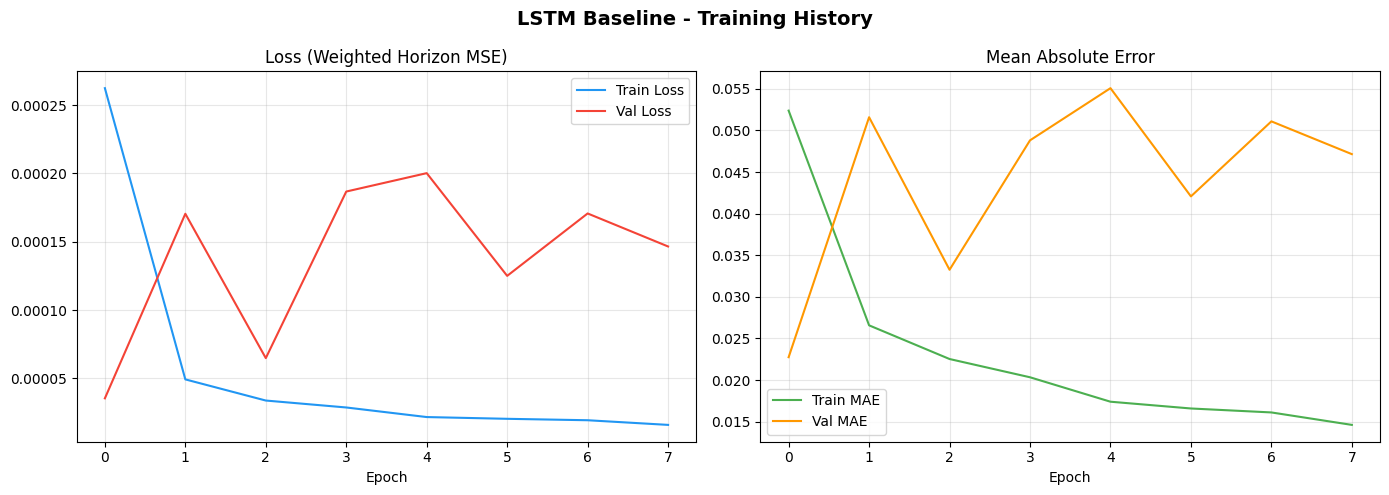

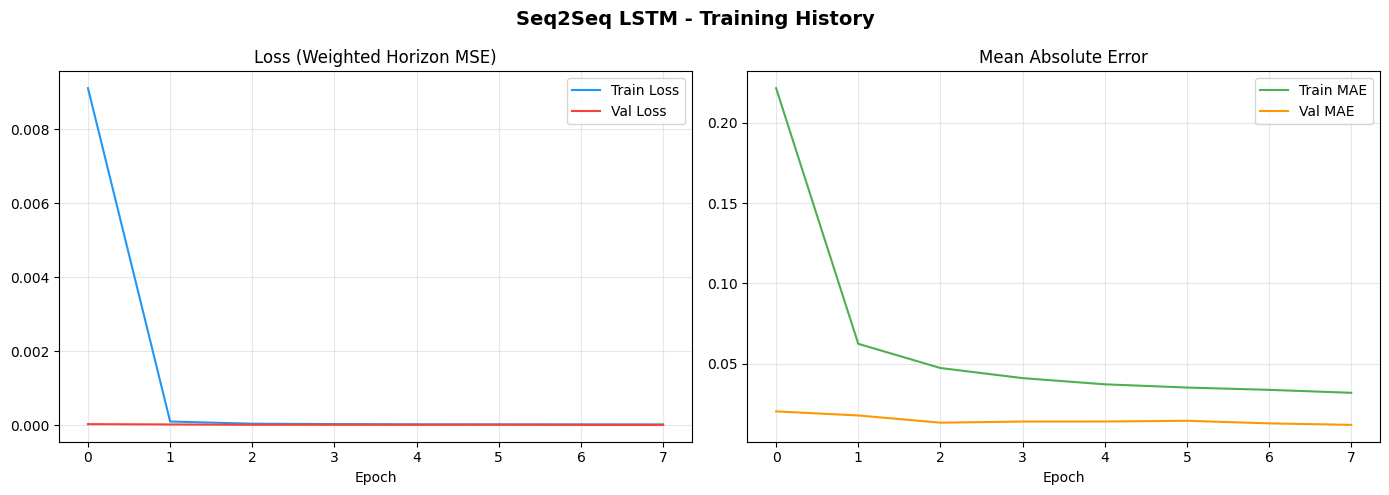

In [24]:
def plot_training_history(history_dict, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    axes[0].plot(history_dict["loss"], label="Train Loss", color="#2196F3")
    axes[0].plot(history_dict["val_loss"], label="Val Loss", color="#F44336")
    axes[0].set_title("Loss (Weighted Horizon MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_dict["mae"], label="Train MAE", color="#4CAF50")
    axes[1].plot(history_dict["val_mae"], label="Val MAE", color="#FF9800")
    axes[1].set_title("Mean Absolute Error")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history_baseline, "LSTM Baseline - Training History")
plot_training_history(history_seq2seq, "Seq2Seq LSTM - Training History")

In [25]:
def inverse_transform_target(scaled_preds, scaler_target):
    return scaler_target.inverse_transform(
        scaled_preds.reshape(-1, 1)
    ).reshape(scaled_preds.shape)

def evaluate_model(
    model,
    X_test,
    y_test,
    scaler_target,
    model_name="Model",
    seq2seq=False,
    horizon=HORIZON
):
    if seq2seq:
        bos    = np.zeros((len(X_test), 1), dtype=np.float32)
        dec_in = np.concatenate([bos, y_test[:, :-1]], axis=1)[:, :, np.newaxis]
        y_pred_scaled = model([X_test, dec_in], training=False).numpy()
    else:
        y_pred_scaled = model(X_test, training=False).numpy()

    y_true_orig  = inverse_transform_target(y_test, scaler_target)
    y_pred_orig  = inverse_transform_target(y_pred_scaled, scaler_target)

    mae_per_step = np.mean(np.abs(y_true_orig - y_pred_orig), axis=0)
    mae_overall  = float(np.mean(mae_per_step))

    print(f"\n{model_name} - Evaluation Results:")
    print(f"   Overall MAE : ${mae_overall:,.2f}")
    print(f"   MAE h+1     : ${mae_per_step[0]:,.2f}")
    print(f"   MAE h+12    : ${mae_per_step[11]:,.2f}")
    print(f"   MAE h+24    : ${mae_per_step[23]:,.2f}")
    return y_true_orig, y_pred_orig, mae_per_step, y_pred_scaled

y_true_b, y_pred_b, mae_b, y_pred_b_scaled = evaluate_model(
    model_baseline,
    X_test,
    y_test,
    scaler_target,
    model_name="LSTM Baseline",
    seq2seq=False,
)

y_true_s, y_pred_s, mae_s, y_pred_s_scaled = evaluate_model(
    model_seq2seq,
    X_test,
    y_test,
    scaler_target,
    model_name="Seq2Seq LSTM (Teacher Forcing)",
    seq2seq=True,
)

print("\nSeq2Seq LSTM - Autoregressive Inference:")
y_pred_ar_scaled = model_seq2seq.predict_autoregressive(
    tf.constant(X_test, dtype=tf.float32)
).numpy()

y_pred_ar_orig = inverse_transform_target(y_pred_ar_scaled, scaler_target)
mae_ar         = float(np.mean(np.abs(y_true_s - y_pred_ar_orig)))
mae_ar_steps   = np.mean(np.abs(y_true_s - y_pred_ar_orig), axis=0)
print(f"   Overall MAE (Autoregressive): ${mae_ar:,.2f}")


LSTM Baseline - Evaluation Results:
   Overall MAE : $1,461.60
   MAE h+1     : $2,307.57
   MAE h+12    : $2,252.93
   MAE h+24    : $2,084.48

Seq2Seq LSTM (Teacher Forcing) - Evaluation Results:
   Overall MAE : $1,053.44
   MAE h+1     : $1,294.51
   MAE h+12    : $621.36
   MAE h+24    : $774.05

Seq2Seq LSTM - Autoregressive Inference:
   Overall MAE (Autoregressive): $1,131.78


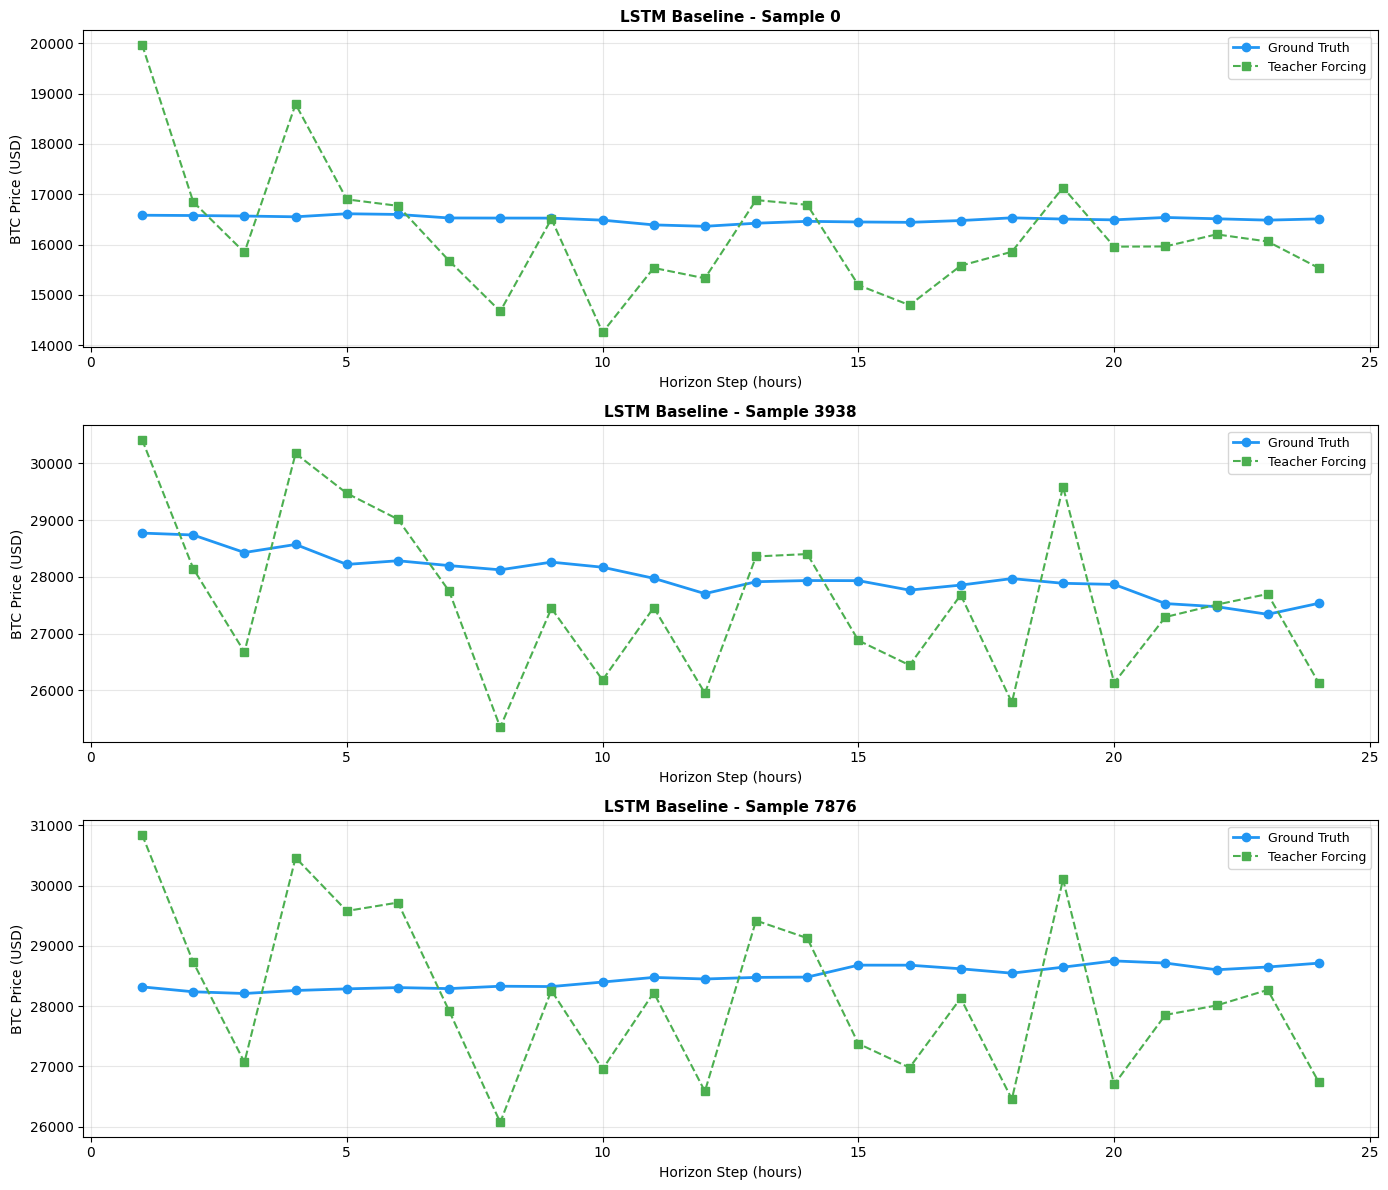

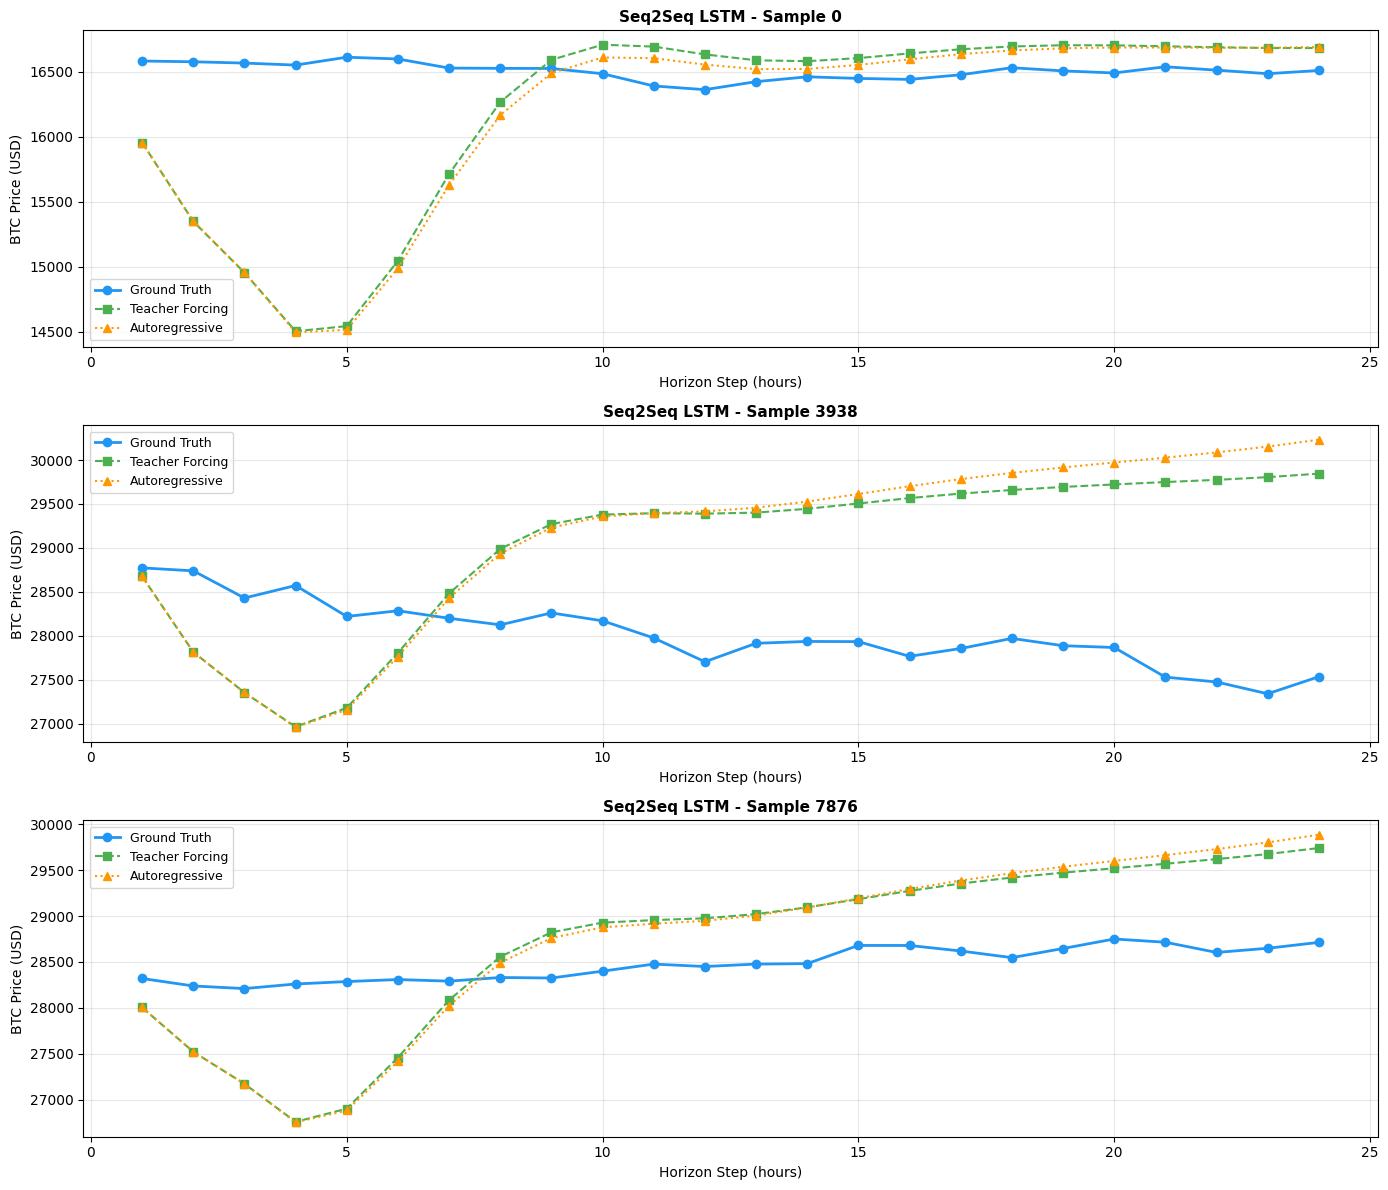

In [26]:
def plot_forecast(
    y_true,
    y_pred_tf,
    y_pred_ar=None,
    n_samples=3,
    horizon=HORIZON,
    title_prefix=""
):
    fig, axes = plt.subplots(n_samples, 1, figsize=(14, 4 * n_samples))
    if n_samples == 1:
        axes = [axes]

    sample_indices = np.linspace(0, len(y_true) - 1, n_samples, dtype=int)

    for ax, idx in zip(axes, sample_indices):
        hours = np.arange(1, horizon + 1)
        ax.plot(hours, y_true[idx], "o-", label="Ground Truth", color="#2196F3", linewidth=2)
        ax.plot(hours, y_pred_tf[idx], "s--", label="Teacher Forcing", color="#4CAF50", linewidth=1.5)
        if y_pred_ar is not None:
            ax.plot(hours, y_pred_ar[idx], "^:", label="Autoregressive", color="#FF9800", linewidth=1.5)
        ax.set_title(f"{title_prefix} - Sample {idx}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Horizon Step (hours)")
        ax.set_ylabel("BTC Price (USD)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_forecast(
    y_true_b,
    y_pred_b,
    y_pred_ar=None,
    n_samples=3,
    title_prefix="LSTM Baseline"
)

plot_forecast(
    y_true_s,
    y_pred_s,
    y_pred_ar=y_pred_ar_orig,
    n_samples=3,
    title_prefix="Seq2Seq LSTM"
)

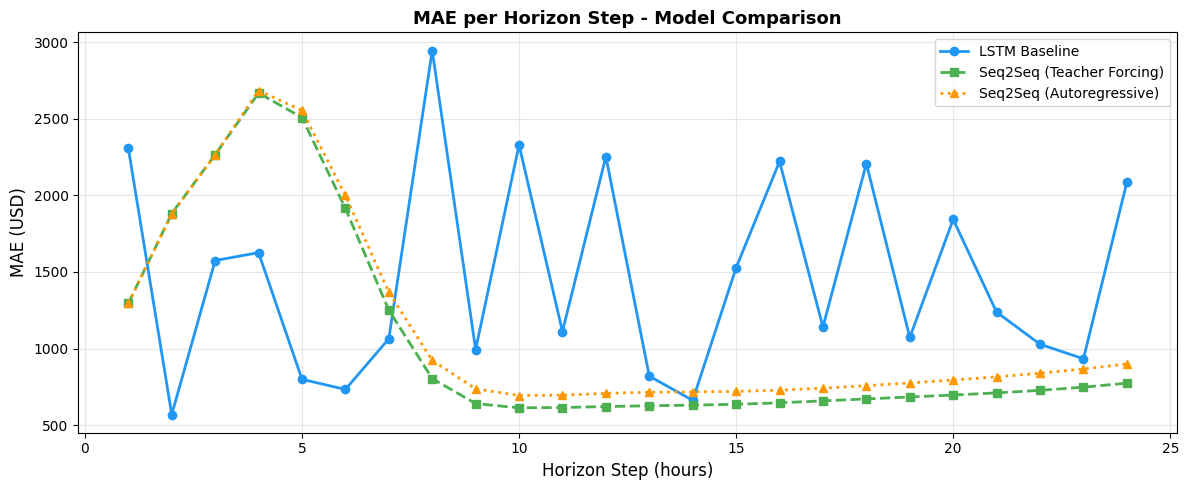

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
hours   = np.arange(1, HORIZON + 1)

ax.plot(hours, mae_b, "o-", label="LSTM Baseline", color="#2196F3", linewidth=2)
ax.plot(hours, mae_s, "s--", label="Seq2Seq (Teacher Forcing)", color="#4CAF50", linewidth=2)
ax.plot(hours, mae_ar_steps, "^:", label="Seq2Seq (Autoregressive)", color="#FF9800", linewidth=2)
ax.set_xlabel("Horizon Step (hours)", fontsize=12)
ax.set_ylabel("MAE (USD)", fontsize=12)
ax.set_title("MAE per Horizon Step - Model Comparison", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
def build_comparison_table(
    y_true,
    y_pred,
    model_name="Model",
    n_windows=5
):
    rows = []
    for win_idx in range(n_windows):
        for step in range(y_true.shape[1]):
            actual    = float(y_true[win_idx, step])
            predicted = float(y_pred[win_idx, step])
            diff      = predicted - actual
            pct_err   = abs(diff) / (actual + 1e-10) * 100
            rows.append({
                "Window": win_idx + 1,
                "Step (h)": step + 1,
                "Actual (USD)": round(actual, 2),
                "Predicted (USD)": round(predicted, 2),
                "Difference (USD)": round(diff, 2),
                "Error (%)": round(pct_err, 2),
            })

    df_table = pd.DataFrame(rows)

    print(f"\n{'='*75}")
    print(f"  {model_name} - Prediction vs Actual (first {n_windows} test windows)")
    print(f"{'='*75}")
    print(df_table.to_string(index=False))
    print(f"\n  Mean |Difference| : ${df_table['Difference (USD)'].abs().mean():,.2f}")
    print(f"  Mean Error %      : {df_table['Error (%)'].mean():.2f}%")
    return df_table

df_table_baseline = build_comparison_table(
    y_true_b,
    y_pred_b,
    model_name="LSTM Baseline",
    n_windows=3,
)

df_table_tf = build_comparison_table(
    y_true_s,
    y_pred_s,
    model_name="Seq2Seq - Teacher Forcing",
    n_windows=3,
)

df_table_ar = build_comparison_table(
    y_true_s,
    y_pred_ar_orig,
    model_name="Seq2Seq - Autoregressive",
    n_windows=3,
)


  LSTM Baseline - Prediction vs Actual (first 3 test windows)
 Window  Step (h)  Actual (USD)  Predicted (USD)  Difference (USD)  Error (%)
      1         1      16583.31         19973.74           3390.43      20.44
      1         2      16577.41         16847.50            270.09       1.63
      1         3      16567.36         15843.99           -723.37       4.37
      1         4      16551.95         18792.04           2240.09      13.53
      1         5      16612.48         16898.53            286.05       1.72
      1         6      16598.95         16770.31            171.36       1.03
      1         7      16528.79         15678.28           -850.51       5.15
      1         8      16526.84         14672.04          -1854.80      11.22
      1         9      16525.78         16509.41            -16.37       0.10
      1        10      16485.45         14254.61          -2230.84      13.53
      1        11      16391.26         15535.53           -855.73       5.22
 

In [29]:
bos_test    = np.zeros((len(X_test), 1), dtype=np.float32)
dec_in_test = np.concatenate([bos_test, y_test[:, :-1]], axis=1)[:, :, np.newaxis]
y_pred_tf_scaled_eval = model_seq2seq([X_test, dec_in_test], training=False).numpy()

mae_scaled_tf = float(np.mean(np.abs(y_test - y_pred_tf_scaled_eval)))
mae_scaled_ar = float(np.mean(np.abs(y_test - y_pred_ar_scaled)))

print("\n" + "=" * 60)
print("  SCALED MAE VERIFICATION (before inverse transform)")
print("=" * 60)
print(f"  Seq2Seq Teacher Forcing - Scaled MAE : {mae_scaled_tf:.6f}  "
      f"{'PASS' if mae_scaled_tf < 0.015 else 'FAIL'}")
print(f"  Seq2Seq Autoregressive  - Scaled MAE : {mae_scaled_ar:.6f}  "
      f"{'PASS' if mae_scaled_ar < 0.015 else 'FAIL'}")


  SCALED MAE VERIFICATION (before inverse transform)
  Seq2Seq Teacher Forcing - Scaled MAE : 0.016093  FAIL
  Seq2Seq Autoregressive  - Scaled MAE : 0.017289  FAIL


In [30]:
print("  FINAL MODEL COMPARISON")
print("=" * 60)
print(f"  LSTM Baseline                 MAE: ${np.mean(mae_b):,.2f}")
print(f"  Seq2Seq (Teacher Forcing)     MAE: ${np.mean(mae_s):,.2f}")
print(f"  Seq2Seq (Autoregressive)      MAE: ${mae_ar:,.2f}")

  FINAL MODEL COMPARISON
  LSTM Baseline                 MAE: $1,461.60
  Seq2Seq (Teacher Forcing)     MAE: $1,053.44
  Seq2Seq (Autoregressive)      MAE: $1,131.78


In [ ]:
# def build_seq2seq_functional(window_size, n_features, horizon, lstm_units=128):
#     enc_inputs = keras.Input(shape=(window_size, n_features), name="encoder_input")

#     enc_x = layers.LSTM(lstm_units, return_sequences=True, name="enc_lstm1")(enc_inputs)
#     enc_x = CustomLayerNorm(name="enc_norm1")(enc_x)
#     enc_x = CustomDropout(rate=0.2, name="enc_drop1")(enc_x)

#     enc_attn = CustomMultiHeadAttention(num_heads=4, key_dim=32, name="enc_mha")(enc_x, enc_x)
#     enc_x    = CustomLayerNorm(name="enc_norm_attn")(enc_x + enc_attn)

#     _, enc_h, enc_c = layers.LSTM(
#         lstm_units,
#         return_sequences=False,
#         return_state=True,
#         name="enc_lstm2",
#     )(enc_x)

#     encoder_states = [enc_h, enc_c]

#     dec_inputs = keras.Input(shape=(horizon, 1), name="decoder_input")

#     dec_x, _, _ = layers.LSTM(
#         lstm_units,
#         return_sequences=True,
#         return_state=True,
#         name="dec_lstm",
#     )(dec_inputs, initial_state=encoder_states)

#     dec_x = CustomLayerNorm(name="dec_norm")(dec_x)
#     dec_x = CustomDropout(rate=0.15, name="dec_drop")(dec_x)

#     dec_cross_attn_layer = CustomMultiHeadAttention(
#         num_heads=4,
#         key_dim=32,
#         name="dec_cross_mha",
#     )

#     dec_attn_out = dec_cross_attn_layer(dec_x, enc_x)
#     dec_x        = CustomLayerNorm(name="dec_norm_attn")(dec_x + dec_attn_out)

#     outputs = CustomDenseLayer(1, activation="linear", name="decoder_output")(dec_x)
#     outputs = layers.Reshape((horizon,), name="reshape_output")(outputs)

#     return Model(
#         inputs=[enc_inputs, dec_inputs],
#         outputs=outputs,
#         name="Seq2Seq_LSTM_TeacherForcing_Functional",
#     )

# model_seq2seq_functional = build_seq2seq_functional(
#     window_size=WINDOW_SIZE,
#     n_features=N_FEATURES,
#     horizon=HORIZON,
#     lstm_units=128,
# )

# model_seq2seq_functional.summary()